In [2]:
import  pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import  matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer
import scipy.stats as stats       # for plotting QQ plot


In [3]:
df= pd.read_csv('./datasets/train.csv', usecols= ['Age', 'Fare', 'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
# fill null values using pand
df['Age'].fillna(df['Age'].mean(), inplace= True)

C:\Users\Yunish\AppData\Local\Temp\ipykernel_20840\2194797952.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace= True)


# Function Transform
- Log Transform  (for right skewed data)
- Square/ square root transform  (for left skewed data)
- Reciprocal Transform

## Know whether the column is normal or not

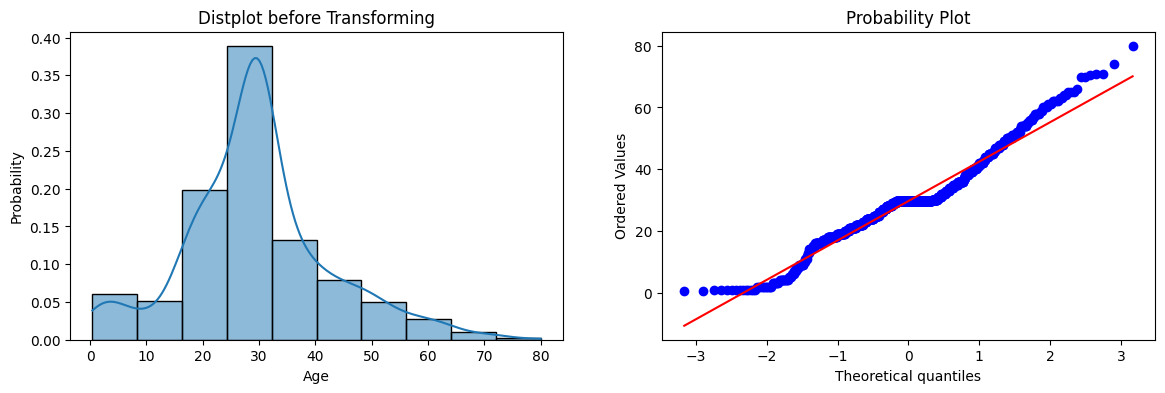

In [7]:
plt.figure(figsize= (14, 4))
plt.subplot(1, 2, 1)
sns.histplot(x= df['Age'], stat= 'probability', bins= 10, kde= True)
plt.title("Distplot before Transforming")

plt.subplot(1,2,2)
plt.title("QQ plot before Transforming")
stats.probplot(df['Age'], plot= plt, dist= 'norm')


plt.show()

In [8]:
df["Age"].skew()

np.float64(0.4344880940129925)

In [9]:
## using Log transformer as it is Right skewed

lt= FunctionTransformer(func= np.log1p)

x= lt.fit_transform(df['Age'])

In [14]:
x= pd.DataFrame(x, columns= ['Age'])


<Axes: title={'center': 'Distplot after Transforming'}, xlabel='Age', ylabel='Probability'>

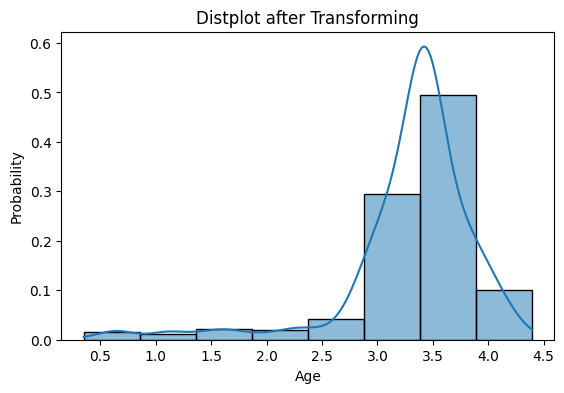

In [17]:
plt.figure(figsize= (14, 4))

plt.subplot(1, 2, 1)
plt.title("Distplot after Transforming")
sns.histplot(x['Age'], kde= True, stat= "probability", bins= 8)